# Power Market Concepts
### An interactive guide to electricity market fundamentals

This notebook covers four core concepts every power trader must understand:

| # | Concept | Key question |
|---|---------|-------------|
| 1 | **Merit Order** | How is the electricity price determined? |
| 2 | **Imbalance** | What happens if you cannot deliver your position? |
| 3 | **Spark Spread** | Should a gas plant run or stay offline? |
| 4 | **Congestion** | Why can't cross-border arbitrage always be exploited? |

Each concept includes an explanation, a calculation, and a visualisation using real or simulated data.

---
> **Prerequisites:** Basic Python, pandas, matplotlib  
> **Data:** SMARD API (Bundesnetzagentur) — German electricity market

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import time

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Libraries loaded.')

Libraries loaded.


---
## Concept 1 — Merit Order

**Core idea:** In electricity markets, generators are ranked by their marginal cost (cheapest first).
The price is set by the **last and most expensive generator** needed to meet demand.
Every generator receives this same price — called **marginal pricing**.

### Why does this matter?
- Renewables (solar, wind) have **zero marginal cost** → always dispatched first
- When renewables cover all demand → price falls to zero or goes **negative**
- A gas peaker sets the price only in high-demand hours → can earn 200+ EUR/MWh
- A solar farm earns the gas price even though its cost is zero → **infra-marginal rent**

### Key term: Infra-marginal rent
The profit earned by cheaper generators because they are paid the marginal price.
Solar owner earns (market price - 0) = full market price per MWh.

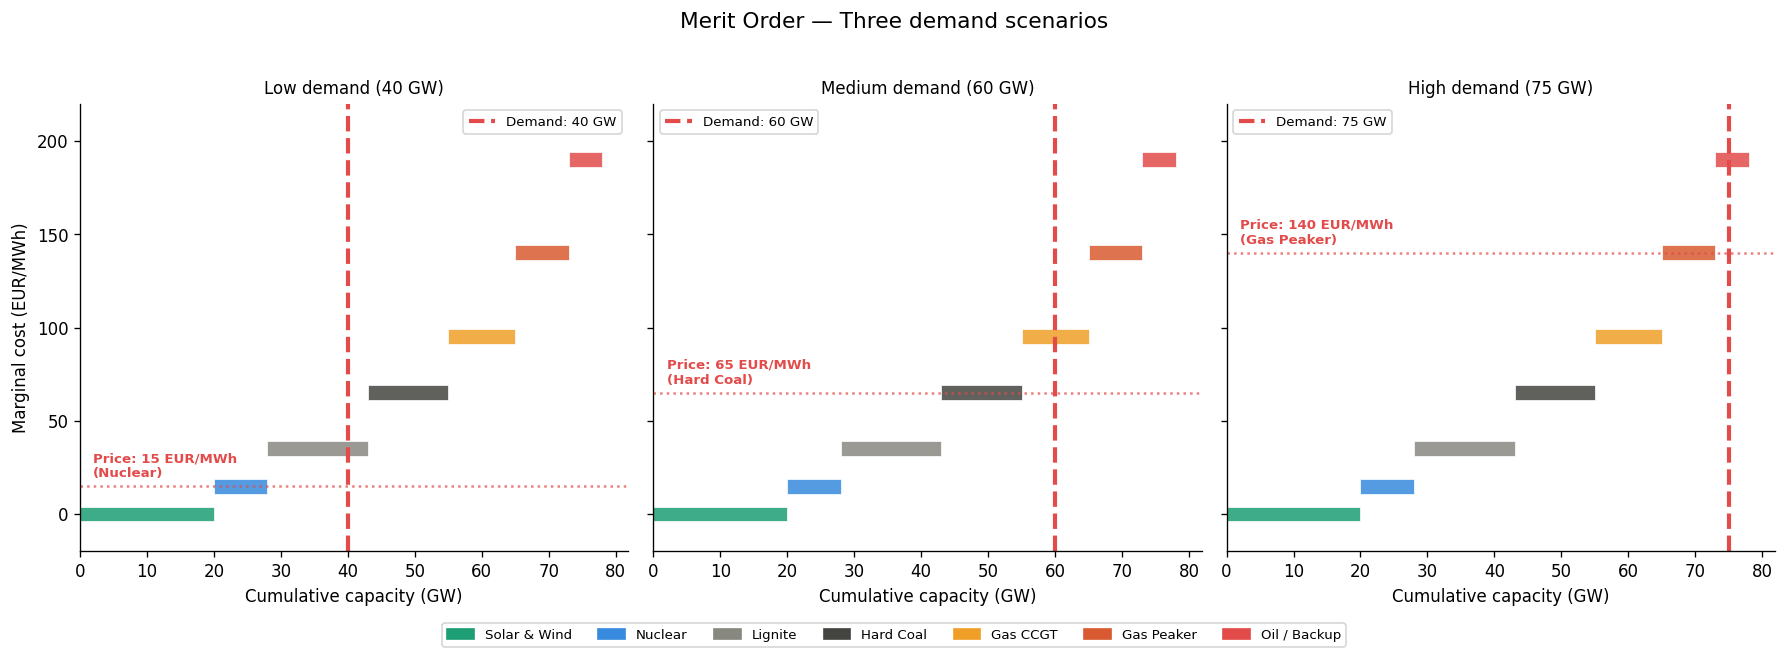

Key insight: the marginal plant sets the price for ALL generators.
Solar earns the same price as gas — even though its fuel cost is zero.


In [2]:
# Merit Order curve — visualisation

plants = [
    {'name': 'Solar & Wind', 'capacity': 20, 'cost': 0,   'color': '#1D9E75'},
    {'name': 'Nuclear',      'capacity': 8,  'cost': 15,  'color': '#378ADD'},
    {'name': 'Lignite',      'capacity': 15, 'cost': 35,  'color': '#888780'},
    {'name': 'Hard Coal',    'capacity': 12, 'cost': 65,  'color': '#444441'},
    {'name': 'Gas CCGT',     'capacity': 10, 'cost': 95,  'color': '#EF9F27'},
    {'name': 'Gas Peaker',   'capacity': 8,  'cost': 140, 'color': '#D85A30'},
    {'name': 'Oil / Backup', 'capacity': 5,  'cost': 190, 'color': '#E24B4A'},
]

demand_scenarios = {
    'Low demand (40 GW)':    40,
    'Medium demand (60 GW)': 60,
    'High demand (75 GW)':   75,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (scenario, demand) in zip(axes, demand_scenarios.items()):
    x = 0
    marginal_cost = 0
    marginal_name = ''
    cumulative = 0

    for p in plants:
        ax.barh(p['cost'], p['capacity'], left=x, height=8,
                color=p['color'], alpha=0.85, edgecolor='white', linewidth=0.5)
        cumulative += p['capacity']
        if cumulative <= demand or marginal_cost == 0:
            marginal_cost = p['cost']
            marginal_name = p['name']
        x += p['capacity']

    ax.axvline(x=demand, color='#E24B4A', linewidth=2.5, linestyle='--', label=f'Demand: {demand} GW')
    ax.axhline(y=marginal_cost, color='#E24B4A', linewidth=1.5, linestyle=':', alpha=0.7)
    ax.text(2, marginal_cost + 5, f'Price: {marginal_cost} EUR/MWh\n({marginal_name})',
            fontsize=8, color='#E24B4A', fontweight='bold')

    ax.set_xlabel('Cumulative capacity (GW)')
    ax.set_title(scenario, fontsize=10)
    ax.set_ylim(-20, 220)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Marginal cost (EUR/MWh)')

legend_patches = [mpatches.Patch(color=p['color'], label=p['name']) for p in plants]
fig.legend(handles=legend_patches, loc='lower center', ncol=7, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Merit Order — Three demand scenarios', fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.show()

print('Key insight: the marginal plant sets the price for ALL generators.')
print('Solar earns the same price as gas — even though its fuel cost is zero.')

Fetching real data from SMARD...
Dataset: 551 hours


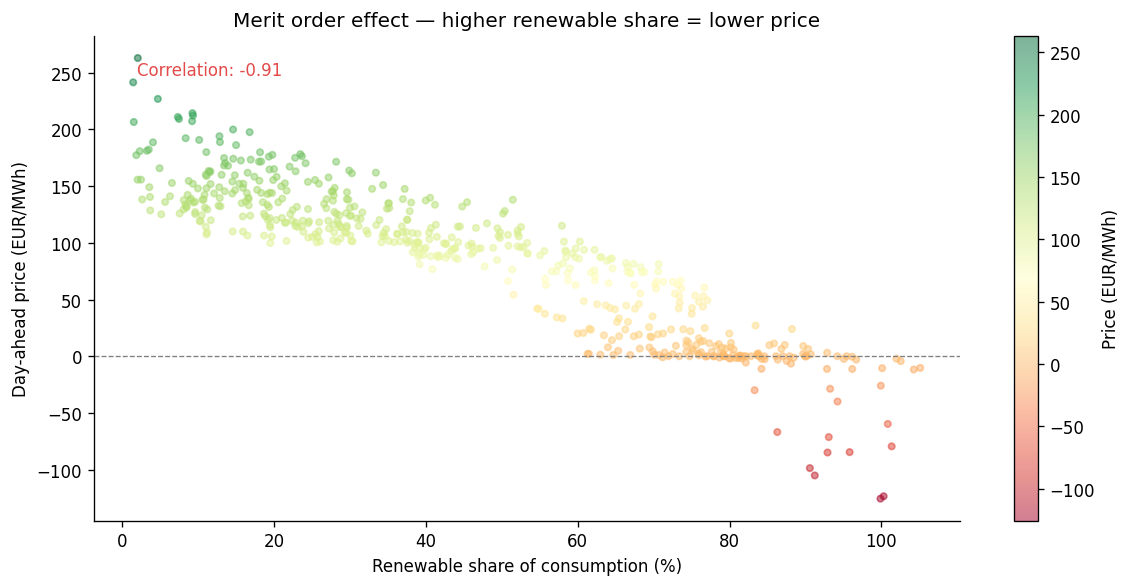

In [3]:
# Merit Order effect — verify with real SMARD data
# Fetch 4 weeks of price + solar + wind data

def fetch_smard(filter_no, col_name, weeks=4):
    url_index = f'https://www.smard.de/app/chart_data/{filter_no}/DE/index_hour.json'
    timestamps = requests.get(url_index).json()['timestamps']
    selected = timestamps[-weeks:]
    series = []
    for ts in selected:
        url = f'https://www.smard.de/app/chart_data/{filter_no}/DE/{filter_no}_DE_hour_{ts}.json'
        series.extend(requests.get(url).json()['series'])
        time.sleep(0.3)
    df = pd.DataFrame(series, columns=['timestamp_ms', col_name])
    df['datetime'] = pd.to_datetime(df['timestamp_ms'], unit='ms')
    return df[['datetime', col_name]]

print('Fetching real data from SMARD...')
df_p = fetch_smard(4169, 'price')
df_w = fetch_smard(4067, 'wind')
df_s = fetch_smard(4068, 'solar')
df_c = fetch_smard(410,  'consumption')

df = df_p.merge(df_w, on='datetime').merge(df_s, on='datetime').merge(df_c, on='datetime')
df = df.dropna()
df['renewables'] = df['wind'] + df['solar']
df['re_share']   = df['renewables'] / df['consumption'] * 100

print(f'Dataset: {len(df)} hours')

# Scatter: renewable share vs price
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(df['re_share'], df['price'],
                c=df['price'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(sc, ax=ax, label='Price (EUR/MWh)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Renewable share of consumption (%)')
ax.set_ylabel('Day-ahead price (EUR/MWh)')
ax.set_title('Merit order effect — higher renewable share = lower price')

corr = df['re_share'].corr(df['price'])
ax.text(0.05, 0.92, f'Correlation: {corr:.2f}', transform=ax.transAxes,
        fontsize=10, color='#E24B4A')
plt.tight_layout()
plt.show()

---
## Concept 2 — Imbalance

**Core idea:** Every market participant must submit a position in the **day-ahead market** (closes 12:00).
If actual production or consumption differs from the committed position, the difference is called an **imbalance**.
The TSO (Transmission System Operator) corrects the imbalance in real time — and charges the responsible party.

### Two directions:
| Direction | Meaning | Consequence |
|-----------|---------|-------------|
| **Short** | Produced/consumed less than committed | TSO sold you energy → you pay imbalance price (usually > spot) |
| **Long**  | Produced/consumed more than committed | TSO bought your surplus → you receive imbalance price (usually < spot) |

### How to manage imbalance risk:
1. **Conservative bidding** — commit less than expected production
2. **Intraday hedging** — buy/sell on intraday market as forecast updates
3. **Portfolio balancing** — offset imbalances across multiple assets

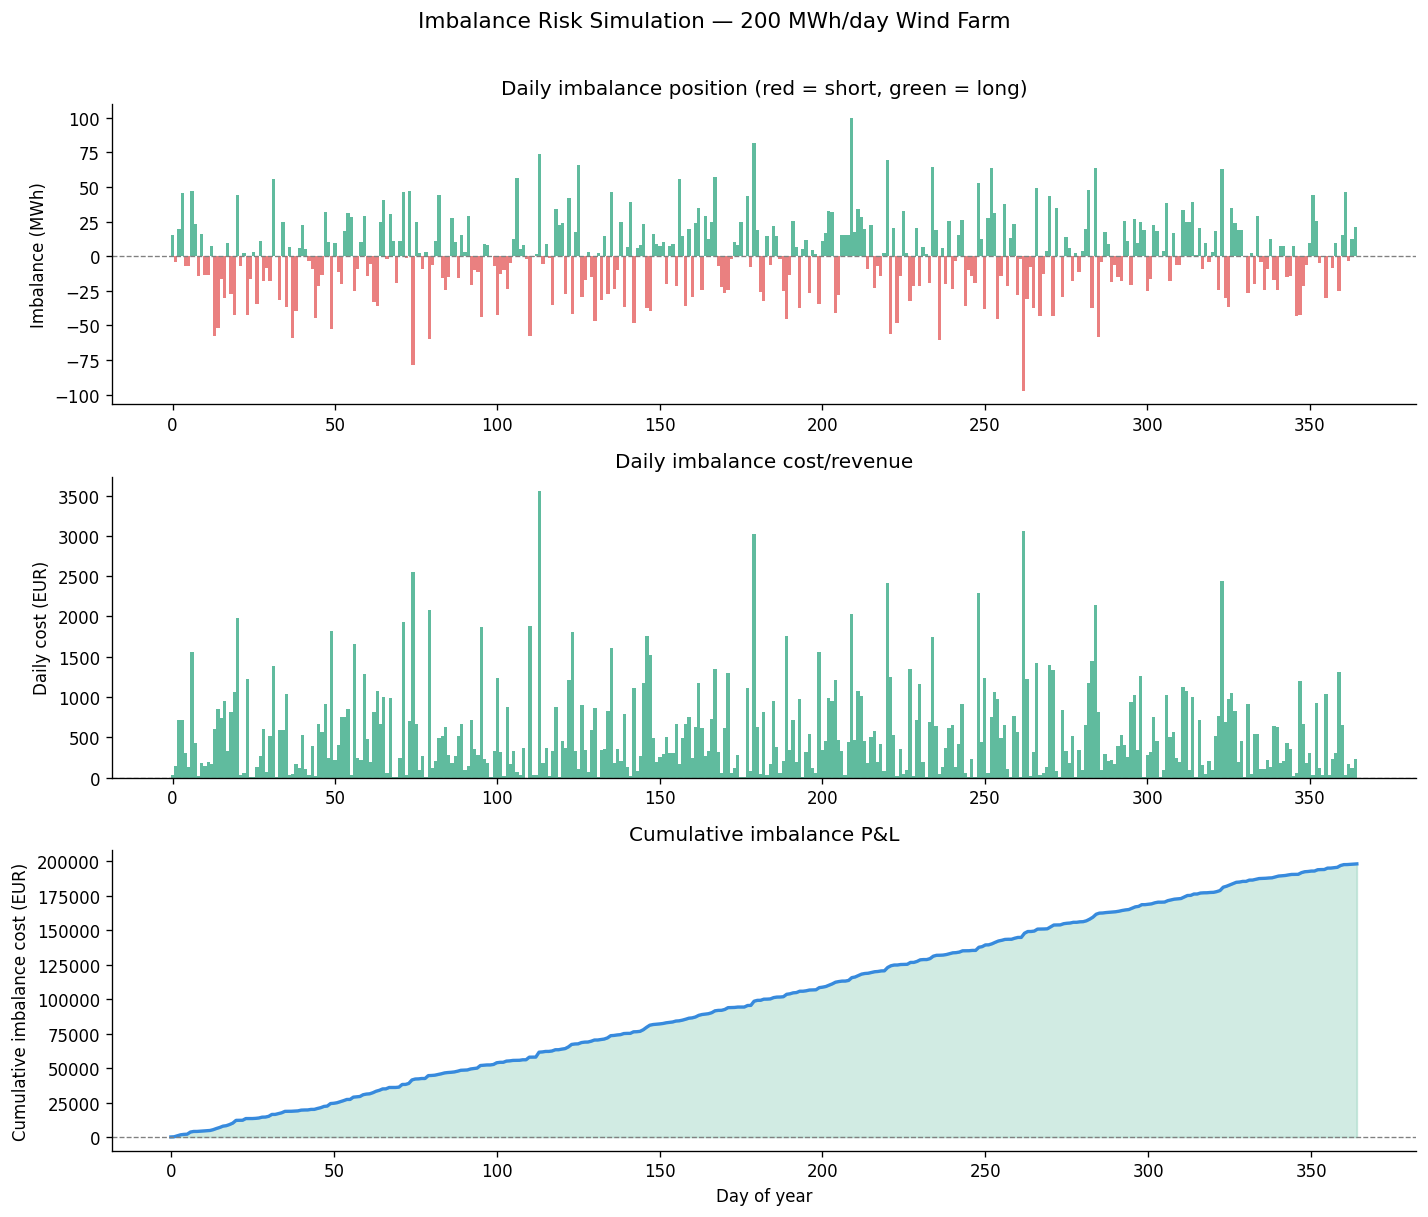

── Imbalance summary ──────────────────────────────
Short days          : 177 (48%)
Long days           : 188 (52%)
Avg imbalance       : 0.3 MWh/day
Annual imbalance cost: 198,057 EUR
Per MWh contracted  : 2.71 EUR/MWh


In [4]:
# Imbalance risk simulation — wind farm
np.random.seed(42)

days              = 365
contracted_mwh    = 200   # day-ahead commitment per day
forecast_error    = 0.15  # 15% standard deviation (typical wind)
imbalance_premium = 0.25  # imbalance price = spot +/- 25%

# Simulate actual production
actual = contracted_mwh * (1 + np.random.normal(0, forecast_error, days))
actual = np.clip(actual, 0, contracted_mwh * 1.5)
imbalance = actual - contracted_mwh

# Simulate spot prices from real data
spot_prices = df['price'].values
spot_sample = np.random.choice(spot_prices[spot_prices > 0], days)

# Imbalance cost
imbalance_price = np.where(
    imbalance < 0,
    spot_sample * (1 + imbalance_premium),  # short: pay more
    spot_sample * (1 - imbalance_premium)   # long: receive less
)
daily_cost = imbalance * (spot_sample - imbalance_price)
cum_cost   = np.cumsum(daily_cost)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: daily imbalance position
colors = ['#E24B4A' if x < 0 else '#1D9E75' for x in imbalance]
axes[0].bar(range(days), imbalance, color=colors, alpha=0.7, width=1)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Imbalance (MWh)')
axes[0].set_title('Daily imbalance position (red = short, green = long)')

# Plot 2: daily imbalance cost
colors2 = ['#E24B4A' if x < 0 else '#1D9E75' for x in daily_cost]
axes[1].bar(range(days), daily_cost, color=colors2, alpha=0.7, width=1)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Daily cost (EUR)')
axes[1].set_title('Daily imbalance cost/revenue')

# Plot 3: cumulative P&L
axes[2].plot(cum_cost, color='#378ADD', linewidth=2)
axes[2].fill_between(range(days), cum_cost, 0,
                     where=(cum_cost < 0), alpha=0.2, color='#E24B4A')
axes[2].fill_between(range(days), cum_cost, 0,
                     where=(cum_cost >= 0), alpha=0.2, color='#1D9E75')
axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('Cumulative imbalance cost (EUR)')
axes[2].set_xlabel('Day of year')
axes[2].set_title('Cumulative imbalance P&L')

plt.suptitle('Imbalance Risk Simulation — 200 MWh/day Wind Farm', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('── Imbalance summary ──────────────────────────────')
print(f'Short days          : {(imbalance < 0).sum()} ({(imbalance < 0).mean()*100:.0f}%)')
print(f'Long days           : {(imbalance > 0).sum()} ({(imbalance > 0).mean()*100:.0f}%)')
print(f'Avg imbalance       : {imbalance.mean():.1f} MWh/day')
print(f'Annual imbalance cost: {cum_cost[-1]:,.0f} EUR')
print(f'Per MWh contracted  : {cum_cost[-1]/(contracted_mwh*days):.2f} EUR/MWh')

---
## Concept 3 — Spark Spread & Clean Spark Spread

**Core idea:** The spark spread measures the profitability of a gas-fired power plant.
It answers the question: *should this plant run or stay offline?*

### Three versions:

| Metric | Formula | What it ignores |
|--------|---------|----------------|
| **Spark spread** | Power price − (Gas price / efficiency) | Carbon cost |
| **Dark spread** | Power price − (Coal price / efficiency) | Carbon cost |
| **Clean spark spread** | Spark spread − CO₂ cost | Nothing — most accurate |

### Decision rule:
- Clean spark spread **> 0** → plant should run (profitable)
- Clean spark spread **= 0** → break-even (marginal plant)
- Clean spark spread **< 0** → plant should stay offline (loss-making)

── Cost structure ──────────────────────────────────
Gas cost (fuel only)  : 80.0 EUR/MWh
Gas CO2 cost          : 52.0 EUR/MWh
Gas all-in cost       : 132.0 EUR/MWh
Coal cost (fuel only) : 30.0 EUR/MWh
Coal CO2 cost         : 138.1 EUR/MWh
Coal all-in cost      : 168.1 EUR/MWh

── Spread summary ──────────────────────────────────
spark_spread             : avg    6.5 | profitable 62% of hours
clean_spark_spread       : avg  -45.5 | profitable 26% of hours
dark_spread              : avg   56.5 | profitable 75% of hours
clean_dark_spread        : avg  -81.7 | profitable 7% of hours


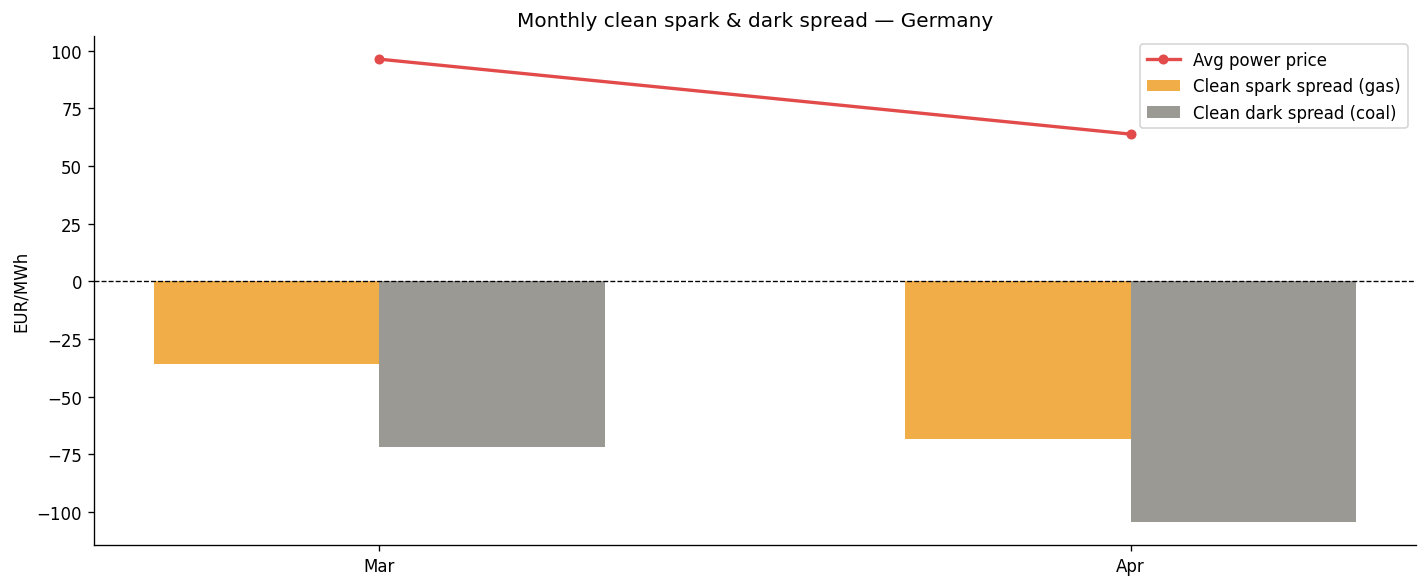

In [5]:
# Spread calculations using real price data

# Market assumptions
GAS_PRICE    = 40    # EUR/MWh (TTF)
COAL_PRICE   = 12    # EUR/MWh (ARA)
CARBON_PRICE = 65    # EUR/ton (EU ETS)
CCGT_EFF     = 0.50  # gas CCGT efficiency
COAL_EFF     = 0.40  # coal plant efficiency
CO2_GAS      = 0.40  # ton CO2 per MWh electricity (gas)
CO2_COAL     = 0.85  # ton CO2 per MWh electricity (coal)

# All-in costs
gas_cost  = GAS_PRICE  / CCGT_EFF
coal_cost = COAL_PRICE / COAL_EFF
co2_gas   = (CO2_GAS  / CCGT_EFF) * CARBON_PRICE
co2_coal  = (CO2_COAL / COAL_EFF) * CARBON_PRICE

print('── Cost structure ──────────────────────────────────')
print(f'Gas cost (fuel only)  : {gas_cost:.1f} EUR/MWh')
print(f'Gas CO2 cost          : {co2_gas:.1f} EUR/MWh')
print(f'Gas all-in cost       : {gas_cost + co2_gas:.1f} EUR/MWh')
print(f'Coal cost (fuel only) : {coal_cost:.1f} EUR/MWh')
print(f'Coal CO2 cost         : {co2_coal:.1f} EUR/MWh')
print(f'Coal all-in cost      : {coal_cost + co2_coal:.1f} EUR/MWh')

# Hourly spreads
df['spark_spread']       = df['price'] - gas_cost
df['clean_spark_spread'] = df['price'] - gas_cost - co2_gas
df['dark_spread']        = df['price'] - coal_cost
df['clean_dark_spread']  = df['price'] - coal_cost - co2_coal

print('\n── Spread summary ──────────────────────────────────')
for col in ['spark_spread','clean_spark_spread','dark_spread','clean_dark_spread']:
    pos = (df[col] > 0).mean() * 100
    print(f'{col:25s}: avg {df[col].mean():6.1f} | profitable {pos:.0f}% of hours')

# Visualise monthly clean spreads
df['month'] = df['datetime'].dt.month
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

monthly = df.groupby('month')[['clean_spark_spread','clean_dark_spread','price']].mean()
monthly.index = [month_labels.get(m, m) for m in monthly.index]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(monthly))
w = 0.3
ax.bar([i - w/2 for i in x], monthly['clean_spark_spread'],
       width=w, color='#EF9F27', alpha=0.85, label='Clean spark spread (gas)')
ax.bar([i + w/2 for i in x], monthly['clean_dark_spread'],
       width=w, color='#888780', alpha=0.85, label='Clean dark spread (coal)')
ax.plot(x, monthly['price'], color='#E24B4A',
        linewidth=2, marker='o', markersize=5, label='Avg power price')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels(monthly.index)
ax.set_ylabel('EUR/MWh')
ax.set_title('Monthly clean spark & dark spread — Germany')
ax.legend()
plt.tight_layout()
plt.show()

---
## Concept 4 — Congestion & Cross-border Arbitrage

**Core idea:** When electricity prices differ between two countries, there is a theoretical arbitrage opportunity.
However, the interconnector between them has a **limited capacity**.
When demand for the interconnector exceeds capacity, the line is **congested** — prices cannot fully equalise.

### How it works:
```
Germany price: 10 EUR/MWh  →  buy here
France price:  80 EUR/MWh  →  sell here
Spread:        70 EUR/MWh  →  profit per MWh

But: DE→FR interconnector = 3,000 MW capacity
If everyone wants to use it → congestion → line fills up
Result: prices converge partially but not fully
```

### Congestion rent:
The revenue from the capacity auction goes to the TSO — called **congestion rent**.  
In the EU, this is redistributed to reduce network tariffs.

### Trader's checklist before cross-border arbitrage:
1. Is the price spread large enough to cover transmission costs?
2. Is interconnector capacity available?
3. Are both positions covered in the respective day-ahead markets?

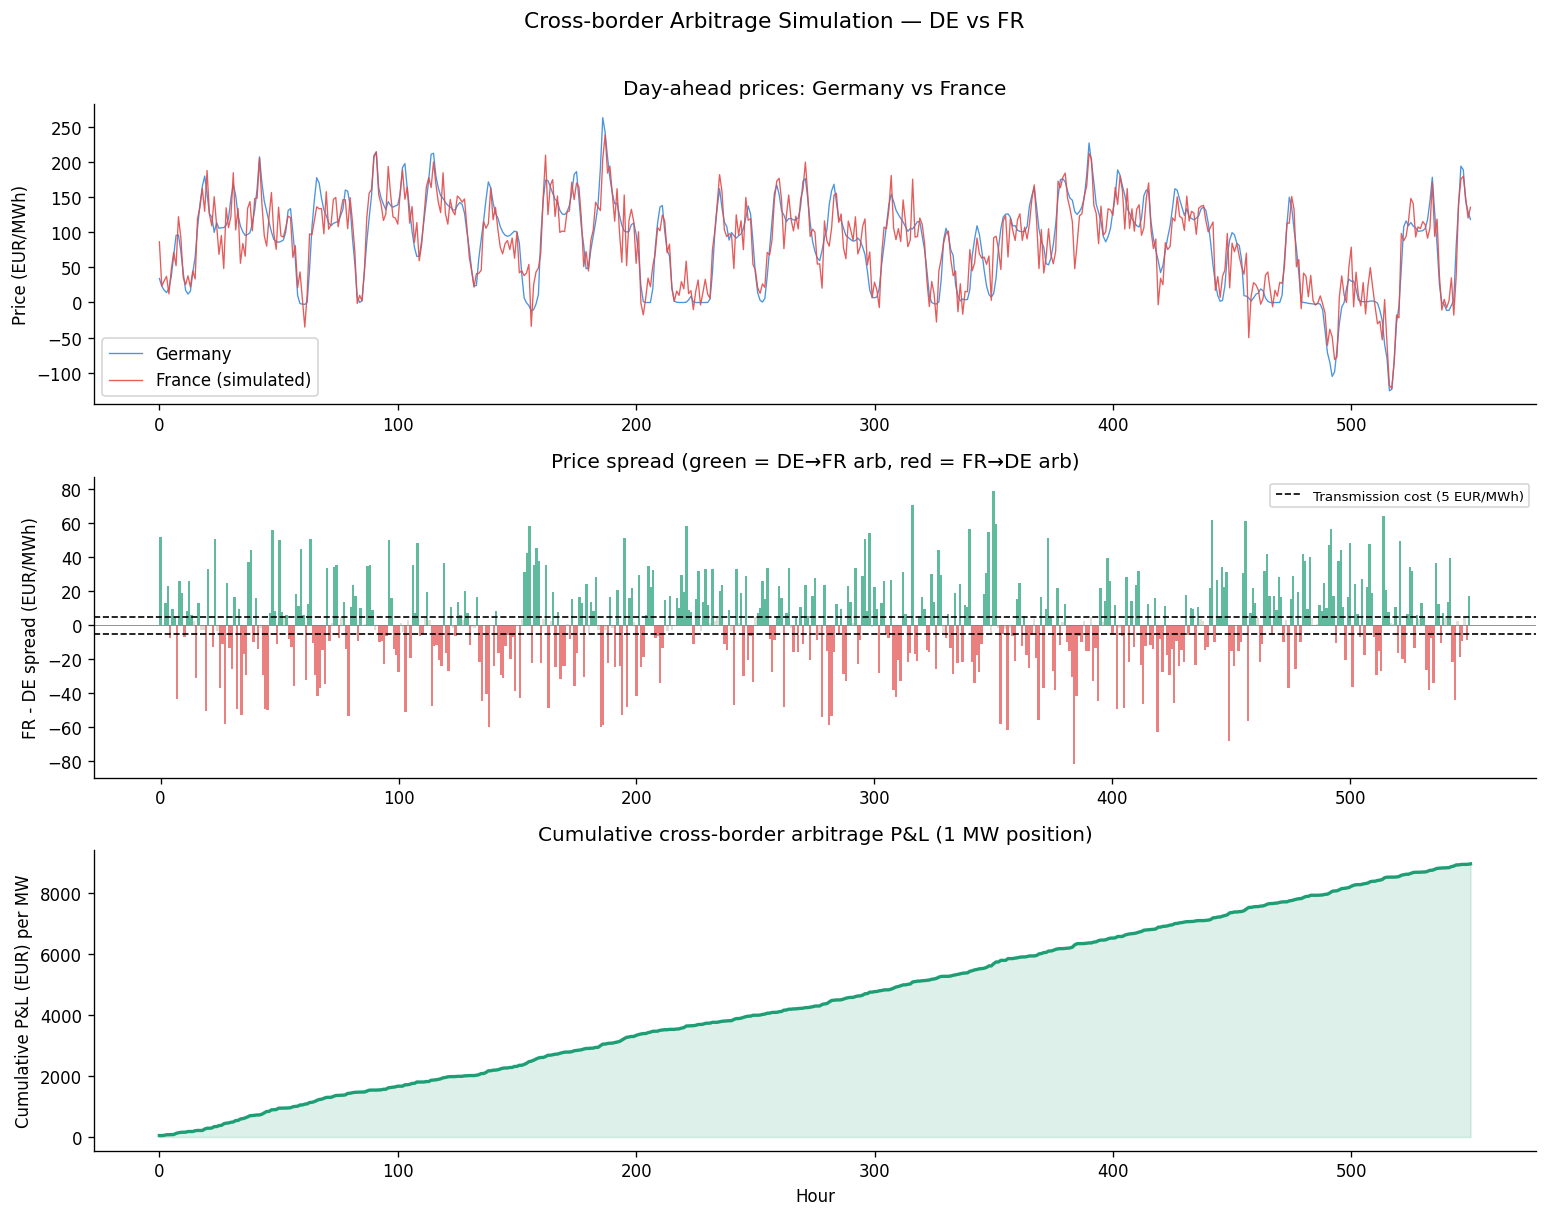

── Cross-border arbitrage summary ──────────────────
Total hours analysed   : 551
DE→FR arb windows      : 241 hrs (43.7%)
FR→DE arb windows      : 236 hrs (42.8%)
Avg spread (arb hours) : 23.8 EUR/MWh
Total P&L (1 MW pos.)  : 8,947 EUR


In [6]:
# Cross-border arbitrage simulation
# Simulates DE vs FR price spread and arbitrage windows

np.random.seed(7)
hours = len(df)

# Simulate FR prices correlated with DE but with random divergence
de_prices = df['price'].values
noise     = np.random.normal(0, 25, hours)
fr_prices = de_prices * 0.85 + 15 + noise

spread         = fr_prices - de_prices
transmission_cost = 5   # EUR/MWh (simplified)
interconnector_cap = 3000  # MW

# Arbitrage opportunity: spread > transmission cost AND capacity available
arb_de_to_fr = spread > transmission_cost    # buy DE, sell FR
arb_fr_to_de = spread < -transmission_cost   # buy FR, sell DE
arb_any      = arb_de_to_fr | arb_fr_to_de

net_profit_per_mwh = np.where(
    arb_de_to_fr,  spread - transmission_cost,
    np.where(arb_fr_to_de, -spread - transmission_cost, 0)
)

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Plot 1: DE vs FR prices
t = range(hours)
axes[0].plot(t, de_prices, color='#378ADD', linewidth=0.8, alpha=0.9, label='Germany')
axes[0].plot(t, fr_prices, color='#E24B4A', linewidth=0.8, alpha=0.9, label='France (simulated)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Day-ahead prices: Germany vs France')
axes[0].legend()

# Plot 2: spread and arbitrage windows
axes[1].bar(t, spread, color=[
    '#1D9E75' if s > transmission_cost
    else '#E24B4A' if s < -transmission_cost
    else '#D3D1C7' for s in spread
], alpha=0.7, width=1)
axes[1].axhline(transmission_cost,  color='black', linewidth=1, linestyle='--',
                label=f'Transmission cost ({transmission_cost} EUR/MWh)')
axes[1].axhline(-transmission_cost, color='black', linewidth=1, linestyle='--')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_ylabel('FR - DE spread (EUR/MWh)')
axes[1].set_title('Price spread (green = DE→FR arb, red = FR→DE arb)')
axes[1].legend(fontsize=8)

# Plot 3: cumulative arbitrage P&L (1 MW position)
cum_arb = np.cumsum(net_profit_per_mwh)
axes[2].plot(t, cum_arb, color='#1D9E75', linewidth=2)
axes[2].fill_between(t, cum_arb, 0, alpha=0.15, color='#1D9E75')
axes[2].set_ylabel('Cumulative P&L (EUR) per MW')
axes[2].set_xlabel('Hour')
axes[2].set_title('Cumulative cross-border arbitrage P&L (1 MW position)')

plt.suptitle('Cross-border Arbitrage Simulation — DE vs FR', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('── Cross-border arbitrage summary ──────────────────')
print(f'Total hours analysed   : {hours}')
print(f'DE→FR arb windows      : {arb_de_to_fr.sum()} hrs ({arb_de_to_fr.mean()*100:.1f}%)')
print(f'FR→DE arb windows      : {arb_fr_to_de.sum()} hrs ({arb_fr_to_de.mean()*100:.1f}%)')
print(f'Avg spread (arb hours) : {abs(spread[arb_any]).mean():.1f} EUR/MWh')
print(f'Total P&L (1 MW pos.)  : {cum_arb[-1]:,.0f} EUR')

---
## Summary

| Concept | Key metric | Trader action |
|---------|-----------|---------------|
| Merit Order | Marginal price | Know which plant sets the price right now |
| Imbalance | Short/Long position | Hedge on intraday market before gate closure |
| Spark Spread | Clean spark spread | Only run the plant if CSS > 0 |
| Congestion | Cross-border spread | Check capacity before arbitrage |

---

## Next steps

- **ENTSO-E API** — fetch real French, Dutch, Norwegian prices for live cross-border analysis
- **Intraday analysis** — how does the spread between day-ahead and intraday evolve?
- **Balancing market** — what are the actual imbalance prices published by the TSO?

> Data source: [SMARD Bundesnetzagentur](https://www.smard.de)  
> ENTSO-E access: transparency@entsoe.eu — subject: 'RESTful API access'